# **Introdução ao Scikit-Learn para Previsão de Retornos de Ações**

**Autor**: Jorge H. N. Viana

**Resumo**: Este notebook introduz o uso da biblioteca `scikit-learn` para
previsão de retornos de ações utilizando modelos de aprendizado de máquina
baseados em árvores. O foco está em dois modelos principais:

1. **Bagging** (*Bootstrap Aggregating*): combinação de múltiplas árvores de
   decisão treinadas em reamostras de bootstrap dos dados;
2. **Gradient Boosting** (GBM): construçao sequencial de árvores, onde cada
   nova árvore corrige os erros da anterior.

O notebook cobre todo o fluxo de ML: coleta e preparação dos dados, divisão
treino-teste, seleção e treinamento dos modelos, otimização de hiperparâmetros
via `RandomizedSearchCV`, avaliação com validação cruzada intertemporal
(`TimeSeriesSplit`) e interpretação via importância por permutação e PDPs
(*Partial Dependence Plots*).

# 1. CARREGAMENTO DOS PACOTES

Nesta seção são importadas as bibliotecas necessárias. Destacam-se:
- `yfinance`: coleta de dados históricos de preços do Yahoo Finance;
- `requests`: requisição HTTP para a API do Banco Central (SELIC);
- `scikit-learn`: pacote central de machine learning:`BaggingRegressor`
  (ensemble bagging), `GradientBoostingRegressor` (boosting), `DecisionTreeRegressor`
  (estimador base), `RandomizedSearchCV` (otimização), `TimeSeriesSplit`
  (validação cruzada temporal), `permutation_importance` e `PartialDependenceDisplay`
  (interpretação);
- `scipy.stats`: distribuições para os espaços de busca dos hiperparâmetros;
- `joblib`: salvamento e carregamento de modelos treinados.

In [32]:
# Pacotes
import numpy as np           
import pandas as pd           
import yfinance as yf  
from datetime import date, timedelta
from pathlib import Path
from multiprocessing import cpu_count
import warnings
import matplotlib.pyplot as plt
import requests
import io
import joblib
import seaborn as sns

from scipy.stats import randint, loguniform, triang, geom

from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error , make_scorer
from sklearn.inspection import permutation_importance,PartialDependenceDisplay

warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

# 2. CONFIGURAÇÕES

Definem-se os parâmetros globais:
- **Período de análise**: 2 anos de dados (de 2025-12-31 retroagindo 2 anos);
- **Diretórios**: *Input*, *Stage*, *Output* e *Figures*;
- **Número de jobs**: metade dos núcleos da CPU, para paralelização durante
  a busca de hiperparâmetros e validação cruzada.

In [33]:
# Define o período de tempo para coleta dos dados
fim    = date(2025, 12, 31)
inicio = fim - timedelta(days=365*2)

# Diretórios
dir_raiz   = "G:\\Meu Drive\\Ensino\\TAF\\taf-code"
input_dir  = Path(dir_raiz, 'Data\\Input\\')
stage_dir  = Path(dir_raiz, 'Data\\Stage\\')
output_dir = Path(dir_raiz, 'Data\\Output\\')
figure_dir = Path(dir_raiz, 'Figures\\')

# Jobs
jobs = cpu_count() // 2

# 3. COLETA E PREPARAÇÃO DOS DADOS

Nesta seção obtêm-se os dados brutos, preços da ação AGRO3.SA e taxa SELIC, e realiza-se o pré-processamento necessário para a modelagem: cálculo de
log-retornos semanais, conversão da SELIC para periodicidade semanal e criação
de variáveis defasadas (*lags*) que servirão como *features* do modelo.

### 3.1 Coleta dos Preços (AGRO3.SA)

Os preços de fechamento ajustados (*Adj Close*) da ação AGRO3.SA são baixados
do Yahoo Finance. O DataFrame resultante tem datas como
índice e ticker como coluna, facilitando operações de reamostragem temporal.

In [34]:
# Define o período de tempo para coleta dos dados
fim    = date.today()
inicio = fim - timedelta(days=365*2)

# Define os ativos a serem utilizados
ativos = ['AGRO3.SA']  

# Coleta os dados do Yahoo Finance
precos = (yf
         .download(ativos, start=inicio, end=fim, 
                   auto_adjust=False)
         ['Adj Close']
         )
precos.head()

[*********************100%***********************]  1 of 1 completed


Ticker,AGRO3.SA
Date,
2024-06-17,23.041668
2024-06-18,22.734808
2024-06-19,23.059717
2024-06-20,23.122896
2024-06-21,22.951414


### 3.2 Taxa SELIC

A taxa SELIC diária é obtida via API do Banco Central (código 1178, formato CSV).
Os dados são lidos com separador `;` e vírgula decimal (padrão brasileiro),
convertidos para `float16` para economia de memória.

In [35]:
api_url = ('https://api.bcb.gov.br/dados/serie/bcdata.sgs.1178/dados?formato=csv&dataInicial={}&dataFinal={}'
           .format(inicio.strftime('%d/%m/%Y'), fim.strftime('%d/%m/%Y')))

selic    = requests.get(api_url)
selic_io = io.StringIO(selic.text)
selic    = (pd.read_csv(selic_io, sep=';', decimal=',') 
            .rename(columns={'valor': 'selic', 'data': 'Date'})
            .assign(Date = lambda x: pd.to_datetime(x['Date'], dayfirst=True))
            .astype({'selic': 'float16'})
            )

selic.head(10)

c:\Users\jorge\miniconda3\envs\JorgeML\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,Date,selic
0,2024-06-17,10.398438
1,2024-06-18,10.398438
2,2024-06-19,10.398438
3,2024-06-20,10.398438
4,2024-06-21,10.398438
5,2024-06-24,10.398438
6,2024-06-25,10.398438
7,2024-06-26,10.398438
8,2024-06-27,10.398438
9,2024-06-28,10.398438


### 3.3 Tratamento

Os dados brutos são transformados em *features* utilizáveis pelos modelos:
log-retornos semanais (target), SELIC semanalizada e defasagens (*lags*) de
1 a 3 períodos tanto do retorno quanto da SELIC. Essas defasagens permitem
que o modelo capture dependências temporais; a ideia é que o retorno passado
contenha informação preditiva sobre o retorno futuro.

#### 3.3.1 Log-Retornos Semanais

Calculam-se os log-retornos semanais pela diferença de logaritmos dos preços
reamostrados para o fechamento de cada domingo (`.resample('W').last()`).
O resultado é transformado para o formato longo com `melt()`, adequado para
operações de *feature engineering* com `groupby` e `shift`.

In [36]:
log_retornos = ((np.log(precos.resample('W').last()) 
                 - np.log(precos.resample('W').last().shift(1))                
                 )
                .dropna()
                .reset_index() 
                .rename_axis(None, axis = 1)
                .melt(id_vars = 'Date', var_name = 'ativo', 
                      value_name = 'retorno')
                .assign(ativo = lambda x: x['ativo'].str.replace('.SA', ''),
                        # retorno = lambda x: x["retorno"]*100
                        )
                )

log_retornos.head()

,Date,ativo,retorno
0,2024-06-30,AGRO3,0.008224
1,2024-07-07,AGRO3,0.053903
2,2024-07-14,AGRO3,0.004793
3,2024-07-21,AGRO3,0.024702
4,2024-07-28,AGRO3,-0.044387


#### 3.3.2 SELIC Semanal

A SELIC anual é convertida para taxa semanal via juros compostos:

$$ R_{\text{semanal}} = (1 + R_{\text{anual}})^{1/52} - 1 $$

A reamostragem semanal usa o último valor disponível em cada semana. Nos períodos
em que a SELIC permaneceu constante, todos os valores semanais serão idênticos
— nessas semanas, a SELIC não contribui com variabilidade preditiva.

In [37]:
selic = (selic
         .assign(selic   = lambda x: x["selic"]/100,
                 selic_w = lambda x: ((1 + x["selic"])**(1/52) - 1) 
                 )
         .set_index('Date')
         .resample('W')
         .last()
         .reset_index()
         )

selic.head(15)

c:\Users\jorge\miniconda3\envs\JorgeML\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,Date,selic,selic_w
0,2024-06-23,0.104004,0.001953
1,2024-06-30,0.104004,0.001953
2,2024-07-07,0.104004,0.001953
3,2024-07-14,0.104004,0.001953
4,2024-07-21,0.104004,0.001953
5,2024-07-28,0.104004,0.001953
6,2024-08-04,0.104004,0.001953
7,2024-08-11,0.104004,0.001953
8,2024-08-18,0.104004,0.001953
9,2024-08-25,0.104004,0.001953


#### 3.3.3 Consolidação dos Dados

Consolidam-se os log-retornos com a SELIC semanal e criam-se 6 variáveis defasadas:
- `retorno_lag_1`, `retorno_lag_2`, `retorno_lag_3`: retornos das 1, 2 e 3
  semanas anteriores;
- `selic_w_lag_1`, `selic_w_lag_2`, `selic_w_lag_3`: SELIC semanal defasada.

As defasagens são calculadas com `groupby('ativo').shift()`, garantindo que
o *shift* não cruze entre ativos diferentes (útil quando houver múltiplas ações).
Linhas com `NaN` (início da série) são removidas com `dropna()`.

O DataFrame final tem 100 observações semanais e será usado como entrada para
os modelos de ML.

In [38]:
dados = (log_retornos
.merge(selic[['Date', 'selic_w']], 
on = 'Date', how = 'left')
.sort_values(['ativo', 'Date'])
.assign(retorno_lag_1 = lambda x: x.groupby('ativo')['retorno'].shift(1),
        retorno_lag_2 = lambda x: x.groupby('ativo')['retorno'].shift(2),
        retorno_lag_3 = lambda x: x.groupby('ativo')['retorno'].shift(3),
        selic_w_lag_1 = lambda x: x['selic_w'].shift(1),
        selic_w_lag_2 = lambda x: x['selic_w'].shift(2),
        selic_w_lag_3 = lambda x: x['selic_w'].shift(3)
        )
.dropna()
.reset_index(drop = True)
)

dados

c:\Users\jorge\miniconda3\envs\JorgeML\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,Date,ativo,retorno,selic_w,retorno_lag_1,retorno_lag_2,retorno_lag_3,selic_w_lag_1,selic_w_lag_2,selic_w_lag_3
0,2024-07-21,AGRO3,0.024702,0.001953,0.004793,0.053903,0.008224,0.001953,0.001953,0.001953
1,2024-07-28,AGRO3,-0.044387,0.001953,0.024702,0.004793,0.053903,0.001953,0.001953,0.001953
2,2024-08-04,AGRO3,-0.038621,0.001953,-0.044387,0.024702,0.004793,0.001953,0.001953,0.001953
3,2024-08-11,AGRO3,0.018540,0.001953,-0.038621,-0.044387,0.024702,0.001953,0.001953,0.001953
4,2024-08-18,AGRO3,-0.006912,0.001953,0.018540,-0.038621,-0.044387,0.001953,0.001953,0.001953
...,...,...,...,...,...,...,...,...,...,...
96,2026-05-24,AGRO3,-0.007989,0.002930,-0.011079,0.024430,-0.065042,0.002930,0.002930,0.002930
97,2026-05-31,AGRO3,0.004269,0.002930,-0.007989,-0.011079,0.024430,0.002930,0.002930,0.002930
98,2026-06-07,AGRO3,-0.004804,0.002930,0.004269,-0.007989,-0.011079,0.002930,0.002930,0.002930
99,2026-06-14,AGRO3,0.006400,0.002930,-0.004804,0.004269,-0.007989,0.002930,0.002930,0.002930


# 4. DIVISÃO DOS DADOS

Antes de treinar qualquer modelo, é necessário separar os dados em conjuntos
de treino e teste. Como se trata de uma série temporal, a divisão deve respeitar
a ordem cronológica, observações futuras não podem "vazar" para o treino.

Aqui são usados dois mecanismos complementares:
1. `train_test_split` com `shuffle=False` para uma divisão simples treino-teste;
2. `TimeSeriesSplit` para validação cruzada que respeita a ordem temporal.

### 4.1 Separação em Features (X) e Target (y)

O target (`y`) é o log-retorno semanal da AGRO3. As *features* (`X`) incluem:
SELIC semanal corrente e defasada (4 variáveis) e retornos defasados (3 variáveis),
totalizando 7 preditores.

> **Nota**: A SELIC corrente (`selic_w`) está disponível no início da semana e
> é conhecida no momento da previsão, portanto é uma *feature* válida.

In [39]:
y = dados['retorno']
X = dados[['selic_w', 'selic_w_lag_1', 'selic_w_lag_2', 'selic_w_lag_3',
           'retorno_lag_1', 'retorno_lag_2', 'retorno_lag_3']]
X.head()

c:\Users\jorge\miniconda3\envs\JorgeML\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,selic_w,selic_w_lag_1,selic_w_lag_2,selic_w_lag_3,retorno_lag_1,retorno_lag_2,retorno_lag_3
0,0.001953,0.001953,0.001953,0.001953,0.004793,0.053903,0.008224
1,0.001953,0.001953,0.001953,0.001953,0.024702,0.004793,0.053903
2,0.001953,0.001953,0.001953,0.001953,-0.044387,0.024702,0.004793
3,0.001953,0.001953,0.001953,0.001953,-0.038621,-0.044387,0.024702
4,0.001953,0.001953,0.001953,0.001953,0.018540,-0.038621,-0.044387


### 4.2 Divisão Treino-Teste

Utiliza-se `train_test_split` com `test_size=1/3` e `shuffle=False`. O parâmetro
`shuffle=False` é essencial para séries temporais: garante que o conjunto de
treino contenha apenas observações anteriores às do teste (~66 treino, ~34 teste).

Se `shuffle=True` fosse usado, haveria *data leakage* — o modelo "veria" o futuro
durante o treino, inflando artificialmente as métricas de avaliação.

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, shuffle=False)

X_train.info()
X.head()

<class 'pandas.core.frame.DataFrame'>
Index: 67 entries, 0 to 66
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   selic_w        67 non-null     float16
 1   selic_w_lag_1  67 non-null     float16
 2   selic_w_lag_2  67 non-null     float16
 3   selic_w_lag_3  67 non-null     float16
 4   retorno_lag_1  67 non-null     float64
 5   retorno_lag_2  67 non-null     float64
 6   retorno_lag_3  67 non-null     float64
dtypes: float16(4), float64(3)
memory usage: 2.6 KB


c:\Users\jorge\miniconda3\envs\JorgeML\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,selic_w,selic_w_lag_1,selic_w_lag_2,selic_w_lag_3,retorno_lag_1,retorno_lag_2,retorno_lag_3
0,0.001953,0.001953,0.001953,0.001953,0.004793,0.053903,0.008224
1,0.001953,0.001953,0.001953,0.001953,0.024702,0.004793,0.053903
2,0.001953,0.001953,0.001953,0.001953,-0.044387,0.024702,0.004793
3,0.001953,0.001953,0.001953,0.001953,-0.038621,-0.044387,0.024702
4,0.001953,0.001953,0.001953,0.001953,0.018540,-0.038621,-0.044387


### 4.3 Validação Cruzada Temporal (TimeSeriesSplit)

O `TimeSeriesSplit` com `n_splits=5` gera 5 divisões treino-teste que respeitam
a ordem cronológica. Em cada *fold*, o conjunto de treino é expandido para
incluir observações mais recentes, enquanto o teste avança no tempo.

Este esquema é mais realista que o K-Fold tradicional para séries temporais,
pois simula o cenário real de previsão: treina-se com o passado, testa-se no
futuro. Será usado no `RandomizedSearchCV` para selecionar hiperparâmetros.

In [41]:
spliter = TimeSeriesSplit(n_splits=5)
spliter

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)

# 5. SELEÇÃO E TREINAMENTO — BAGGING REGRESSOR

O **Bagging** (*Bootstrap Aggregating*) é um método de *ensemble* que treina
múltiplos estimadores (por padrão, árvores de decisão) em subamostras bootstrap
dos dados e agrega as previsões pela média:

$$ \hat{y} = \frac{1}{B} \sum_{b=1}^{B} \hat{f}_b(x) $$

onde $B$ é o número de estimadores (árvores) e $\hat{f}_b$ é a previsão da
$b$-ésima árvore.

O Bagging reduz a variância em relação a uma árvore única, sendo particularmente
eficaz para estimadores de alta variância como árvores de decisão profundas.
O modelo inicial usa os hiperparâmetros padrão do scikit-learn.

In [42]:
model_bagg = BaggingRegressor(random_state=42)
model_bagg.fit(X_train, y_train)

BaggingRegressor(random_state=42)

# 6. AVALIAÇÃO DO MODELO

A avaliação de modelos de regressão em séries temporais requer métricas adequadas
e, idealmente, validação cruzada que respeite a ordem dos dados. Nesta seção,
compara-se a avaliação *sem* e *com* validação cruzada temporal.

A métrica principal é o **RMSE** (*Root Mean Squared Error*), que mede o erro
de previsão na mesma unidade da variável resposta:

$$ RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} $$

### 6.1 Avaliação sem Validação Cruzada

Calcula-se o RMSE do modelo Bagging diretamente no conjunto de teste (34 semanas).
Embora simples, esta abordagem é sensível à partição específica, diferentes
divisões treino-teste podem produzir resultados distintos.

Também são reportados MAPE (*Mean Absolute Percentage Error*) como métrica complementar.

In [43]:
y_pred_bagg = model_bagg.predict(X_test)

mape_bagg = mean_absolute_percentage_error(y_test,
                                           y_pred_bagg)
rmse_bagg = root_mean_squared_error(y_test, 
                                       y_pred_bagg)

print(f"MAPE of Bagging Classifier: {mape_bagg:.4f}")
print(f"RMSE of Bagging Classifier: {rmse_bagg:.4f}")

MAPE of Bagging Classifier: 1.3488
RMSE of Bagging Classifier: 0.0331


### 6.2 Avaliação com Validação Cruzada Temporal

Utiliza-se `cross_val_score` com `TimeSeriesSplit` para obter uma estimativa
mais robusta do erro de generalização. Cada *fold* avalia o modelo em uma
janela futura diferente, e a média dos RMSEs dos 5 folds fornece uma medida
menos dependente de uma única partição.

#### 6.2.1 RMSE Médio

O RMSE médio da validação cruzada é calculado. Comparado ao RMSE sem CV,
este valor é geralmente mais conservador (maior), pois reflete o desempenho
em múltiplas janelas temporais, incluindo períodos potencialmente mais difíceis
de prever.

In [44]:
cv_bagg = cross_val_score(model_bagg, 
            X_train, y_train, 
            cv = spliter, 
            scoring = 'neg_root_mean_squared_error',
            n_jobs = jobs
            )

# Convert negative RMSE to positive
cv_bagg = -cv_bagg

print(f"Mean RMSE: {cv_bagg.mean():.4}")

Mean RMSE: 0.02291


# 7. OTIMIZAÇÃO DE HIPERPARÂMETROS

Nesta seção, utiliza-se `RandomizedSearchCV` para encontrar a melhor combinação
de hiperparâmetros do Bagging. A busca é feita em duas etapas:

1. Otimização apenas do meta-estimador (`n_estimators`, `max_features`);
2. Inclusão dos parâmetros do estimador base (`max_depth`, `min_samples_leaf`).

O `RandomizedSearchCV` explora aleatoriamente o espaço de hiperparâmetros,
sendo mais eficiente que o `GridSearchCV` quando o espaço é grande. Aqui são
amostradas 100 combinações, com validação cruzada `TimeSeriesSplit` (5 folds).

### 7.1 Otimização do Meta-Estimador

Otimizam-se apenas os parâmetros do Bagging:
- `n_estimators` (10–95): número de árvores no ensemble — mais árvores reduzem
  a variância, mas aumentam o custo computacional;
- `max_features` (0.5–1.0): fração de *features* usadas em cada subamostra —
  valores menores aumentam a diversidade entre as árvores.

O estimador base (`DecisionTreeRegressor`) usa os parâmetros padrão nesta etapa.

In [45]:
# Definindo o espaço de busca para os hiperparâmetros
param_dist = {
'n_estimators': range(10, 100, 5),
'max_features': np.linspace(0.5, 1.0, 10),
}

# Criando o RandomizedSearchCV
random_search = RandomizedSearchCV(
                estimator=model_bagg,
                param_distributions=param_dist,
                n_iter=100,
                cv=spliter,
                scoring='neg_root_mean_squared_error',
                n_jobs=jobs,
                random_state=42
                )

# Executando a busca
random_search.fit(X_train, y_train)

# Melhor conjunto de hiperparâmetros
best_params = random_search.best_params_
best_score = -random_search.best_score_
print(f"Best Param: {best_params}")
print(f"Optimized RMSE: {best_score: .4}")

Best Param: {'n_estimators': 90, 'max_features': np.float64(0.5)}
Optimized RMSE:  0.02116


### 7.2 Otimização Conjunta (Meta + Estimador Base)

Além dos parâmetros do Bagging, incluem-se os do estimador base (`estimator__`):
- `estimator__max_depth` (3–14): profundidade máxima das árvores — limita o
  *overfitting*;
- `estimator__min_samples_leaf` (1–5): número mínimo de amostras em uma folha —
  outro regularizador contra *overfitting*.

A sintaxe `estimator__` é a convenção do scikit-learn para acessar parâmetros
de estimadores aninhados. O RMSE otimizado tipicamente cai ao permitir
regularização nas árvores base.

In [46]:
# Reinstanciando Bagging
estimator = DecisionTreeRegressor(random_state=42)

model_bagg = BaggingRegressor(estimator=estimator,
                              random_state=42)

# Novo espaço de busca
param_dist = {
              'n_estimators': range(10, 100, 5),
              'max_features': np.linspace(0.5, 1.0, 10),
              'estimator__max_depth': range(3, 15),
              'estimator__min_samples_leaf': range(1, 6) 
              }

# Criando o RandomizedSearchCV
random_search = RandomizedSearchCV(
                                    estimator=model_bagg,
                                    param_distributions=param_dist,
                                    n_iter=100,
                                    cv=spliter,
                                    scoring='neg_root_mean_squared_error',
                                    n_jobs=jobs,
                                    random_state=42
                                    )

# Executando a busca
random_search.fit(X_train, y_train)
# Melhor conjunto de hiperparâmetros
best_params = random_search.best_params_
best_score = -random_search.best_score_
print(f"Optimized RMSE: {best_score: .4}")

Optimized RMSE:  0.01938


### 7.3 Modelo Ótimo

Com os melhores hiperparâmetros encontrados, instancia-se o `BaggingRegressor`
ótimo, treina-se nos dados de treino e salva-se em disco com `joblib.dump()`.
O modelo salvo pode ser carregado posteriormente com `joblib.load()` sem
necessidade de re-treino, economizando tempo em análises futuras.

In [47]:
# Estimação do modelo ótimo
opt_bagg = BaggingRegressor(
    n_estimators=best_params['n_estimators'],
    max_features=best_params['max_features'],
    random_state=42 
)

# Treinando o modelo ótimo
opt_bagg.fit(X_train, y_train)

# Exportação do modelo
opt_bagg_path = Path(output_dir, 'opt_bagg.pkl')
joblib.dump(opt_bagg, opt_bagg_path)
opt_bagg

BaggingRegressor(max_features=np.float64(0.8888888888888888), n_estimators=20,
                 random_state=42)

# 8. INTERPRETAÇÃO DO MODELO (BAGGING)

Modelos de *ensemble* como Bagging são tradicionalmente "caixa-preta". Para
entender *quais features* o modelo considera mais importantes e *como* cada
feature afeta as previsões, utilizam-se duas técnicas *model-agnostic*:

- **Permutation Importance**: mede a queda no desempenho quando uma feature é
  embaralhada, quebrando sua relação com o target;
- **PDP** (*Partial Dependence Plot*): mostra a relação média entre uma feature
  e a previsão, marginalizando sobre as demais.

### 8.1 Importância por Permutação

A importância por permutação é calculada com `permutation_importance` usando
o conjunto de teste. Para cada feature, o procedimento é:
1. Embaralhar aleatoriamente os valores da feature (quebrando a relação com o target);
2. Medir a queda no desempenho (RMSE) em relação ao modelo original;
3. Repetir `n_repeats=20` vezes para obter uma distribuição da importância.

Features com importância alta (grande aumento no RMSE ao serem permutadas) são
as mais relevantes para o modelo. A tabela exibe a importância normalizada,
onde 100% corresponde à feature mais importante.

In [48]:
# Criação da métrica
rmse = make_scorer( root_mean_squared_error,
                   greater_is_better = False)

# Calcula a permutation importance
importance = permutation_importance(opt_bagg,
            X_test, y_test,
            scoring = rmse,
            n_repeats = 100, 
            random_state=42,
            n_jobs=jobs)

# Cria um DataFrame para armazenar os importanceados
importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': importance.importances_mean,
    'importance_std': importance.importances_std
})

# Ordena o DataFrame pela importância média
importance_df = (importance_df
                 .query('importance_mean > 0')
                 .drop(columns = 'importance_std')
                 .assign(importance_mean_max = lambda x: x["importance_mean"].max(),                         
                         importance_mean     = lambda x: round( ( x["importance_mean"] / 
                                                                  x['importance_mean_max'] ) * 100, 0 )
                       )
                 .sort_values(by='importance_mean',
                               ascending=False)
                 .reset_index(drop=True)
                 )

importance_df

,feature,importance_mean,importance_mean_max
0,retorno_lag_1,100.0,0.000634
1,retorno_lag_3,44.0,0.000634


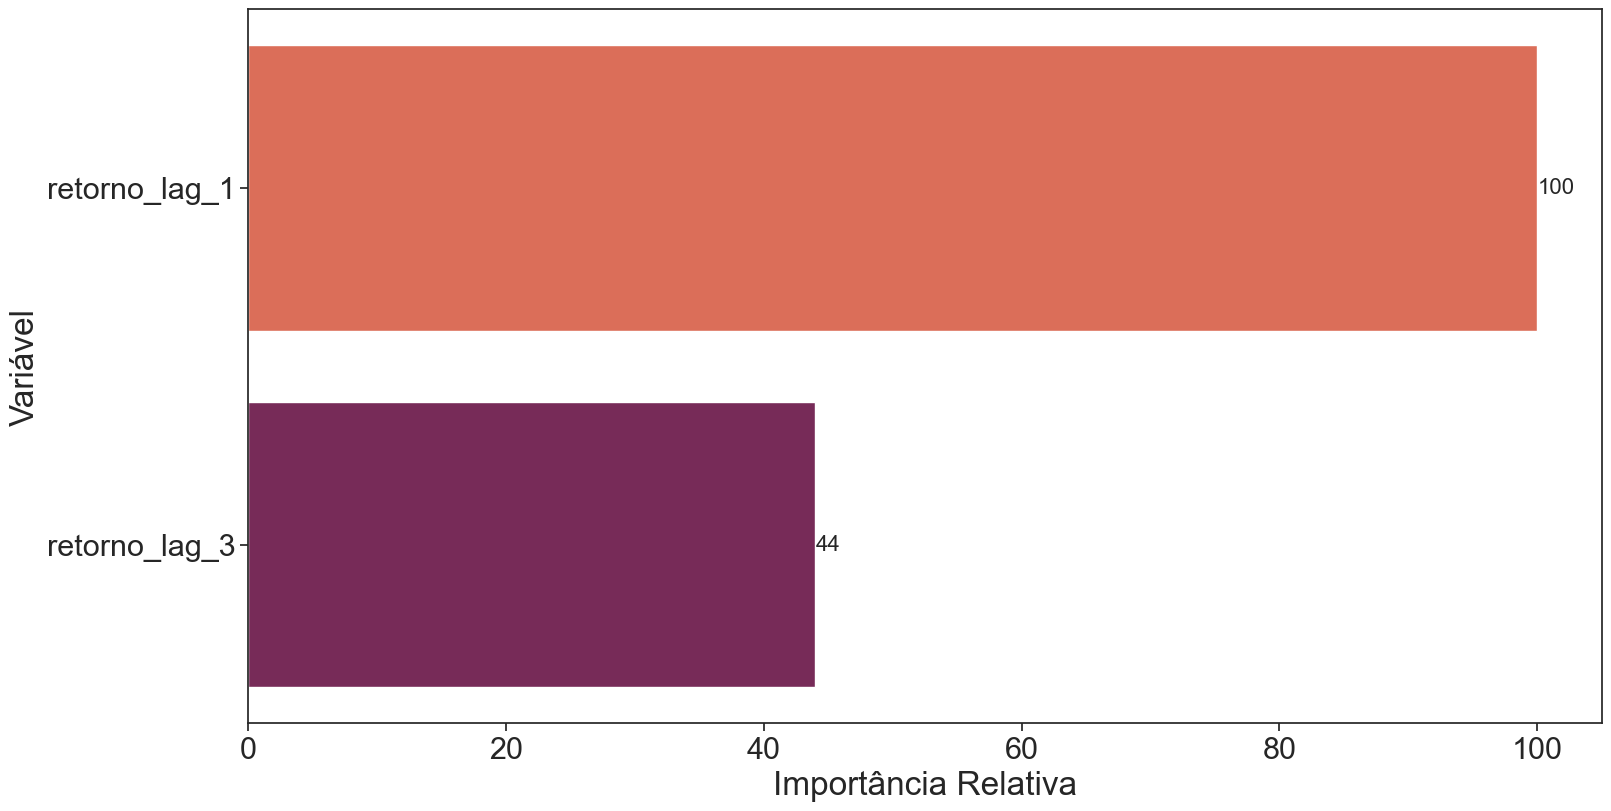

In [49]:
# VIP
plt.figure(figsize=(16, 8), layout = 'constrained')
sns.set(style = "ticks")
figure = sns.barplot(data = importance_df, x = 'importance_mean', y = 'feature', orient = 'h', 
                        err_kws={'linewidth': 0}, palette = "rocket_r", hue = 'feature')
plt.xlabel("Importância Relativa", fontsize = 24)
plt.ylabel("Variável", fontsize = 24)
plt.tick_params(axis = 'both', which = 'major', labelsize = 22)
for container in range(0, len(figure.containers)):
    plt.bar_label(figure.containers[container], fontsize = 16)
figure.get_figure().savefig( Path(figure_dir, 'vip_bagg' + '.png'), dpi = 400)

### 8.2 Gráficos de Dependência Parcial (PDPs)

Os PDPs mostram o efeito marginal de cada feature na previsão do modelo,
mantendo as demais constantes em seus valores médios. O `PartialDependenceDisplay`
do scikit-learn gera automaticamente os gráficos.

> **Interpretação**: Uma curva PDP plana indica que a feature tem pouco efeito
> na previsão. Uma curva com inclinação acentuada indica relação forte. O sinal
> da inclinação revela se a relação é positiva ou negativa. Por exemplo, se o
> PDP do `retorno_lag_1` for positivo, o modelo aprendeu que retornos positivos
> tendem a ser seguidos por mais retornos positivos (efeito momentum).

In [50]:
# Seleciona as features para as quais queremos criar os PDPs
features = (importance_df
            .nlargest(5, columns = 'importance_mean') 
            ['feature']
            .to_list()
            )

# Cria os PDPs
for feature in features:
    plt.close()
    fig, ax = plt.subplots(figsize=(16, 9))
    PartialDependenceDisplay.from_estimator(opt_bagg, 
                            X_train, 
                            features = [feature], 
                            grid_resolution=100,
                            line_kw={"color": "#e60000"},
                            n_jobs = jobs,
                            ax=ax
                            )
    plt.xlabel(feature, fontsize = 22)
    plt.ylabel("Dependência Parcial", fontsize = 22)
    plt.tick_params(axis = 'both', which = 'major', labelsize = 18)
    sns.set(style = "ticks")
    fig.savefig(Path(figure_dir, f'pdp_bagg_{feature}.png'), dpi=400)
    plt.close()

# 9. APLICAÇÃO — GRADIENT BOOSTING (GBM)

O **Gradient Boosting** é uma alternativa ao Bagging que constrói árvores
sequencialmente: cada nova árvore é treinada para corrigir os erros residuais
do ensemble atual. Enquanto o Bagging reduz a variância (árvores independentes),
o Boosting reduz principalmente o viés.

Nesta seção, o fluxo completo é repetido para o `GradientBoostingRegressor`,
permitindo comparar as duas abordagens para o mesmo problema de previsão.

> **Nota**: O GBM tende a ter melhor desempenho preditivo que o Bagging em
> muitos problemas, mas é mais sensível a *overfitting* e requer ajuste mais
> cuidadoso dos hiperparâmetros, especialmente `learning_rate` e `n_estimators`.

### 9.1 Otimização de Hiperparâmetros (GBM)

O espaço de busca do GBM inclui parâmetros específicos:
- `n_estimators` (50–300): número de árvores no boosting;
- `learning_rate` (distribuição log-uniforme): controla a contribuição de cada
  árvore — valores baixos exigem mais árvores, mas produzem modelos mais robustos;
- `max_depth` (3–10): profundidade das árvores;
- `min_samples_leaf` (1–10) e `min_samples_split` (2–20): regularizadores;
- `subsample` (0.6–1.0): fração de amostras usadas em cada iteração (*stochastic
  gradient boosting*).

A busca aleatória (`RandomizedSearchCV`) amostra 100 combinações e avalia via
`TimeSeriesSplit`. O *scoring* é o RMSE negativo (`neg_root_mean_squared_error`),
convenção do scikit-learn onde "maior é melhor".

In [51]:
# Instaciando o Estimador de GBM
model_gbm  = GradientBoostingRegressor(random_state=42)

# Novo espaço de busca
param_dist = {            
'n_estimators': geom(p=0.04, loc=9), 
'max_features':triang(c=0, loc=0.5, scale=0.5),
'max_depth': randint(3, 15),
'min_samples_leaf': randint(1, 6),
'learning_rate': loguniform(0.001, 0.5)
}

# Criando o RandomizedSearchCV
search_gbm = RandomizedSearchCV(
                estimator=model_gbm,
                param_distributions=param_dist,
                n_iter=100,
                cv=spliter,
                scoring='neg_root_mean_squared_error',
                n_jobs=jobs,
                random_state=42
                )

# Executando a busca
search_gbm.fit(X_train, y_train)
# Melhor conjunto de hiperparâmetros
best_params_gbm = search_gbm.best_params_
best_score_gbm = -search_gbm.best_score_
print(f"Optimized RMSE: {best_score_gbm}")

Optimized RMSE: 0.019413433180147873


### 9.2 Modelo Ótimo (GBM)

Instancia-se o `GradientBoostingRegressor` com os melhores hiperparâmetros
encontrados e treina-se nos dados de treino. A métrica de desempenho (RMSE) no conjunto de teste é comparada com as do Bagging.

> **Comparação esperada**: Em geral, o GBM tende a apresentar RMSE inferior
> ao Bagging, mas a diferença depende da relação sinal-ruído dos dados. Se o
> GBM não superar o Bagging, pode ser um indicativo de que os ganhos do boosting
> são limitados pela previsibilidade intrínseca dos retornos.

In [52]:
# Estimação do modelo ótimo
opt_gbm = GradientBoostingRegressor(
    n_estimators = best_params_gbm['n_estimators'],
    max_features = best_params_gbm['max_features'],
    max_depth = best_params_gbm['max_depth'],
    min_samples_leaf = best_params_gbm['min_samples_leaf'],
    learning_rate = best_params_gbm['learning_rate'],
    random_state=42 
)

# Treinando o modelo ótimo
opt_gbm.fit(X_train, y_train)

# Exportação do modelo
opt_gbm_path = Path(output_dir, 'opt_gbm.pkl')
joblib.dump(opt_gbm, opt_gbm_path)
opt_gbm

GradientBoostingRegressor(learning_rate=np.float64(0.04348777880861619),
                          max_depth=11,
                          max_features=np.float64(0.580557961603776),
                          min_samples_leaf=5, n_estimators=11, random_state=42)

### 9.3 Interpretação do GBM

Repetem-se as técnicas de interpretação para o modelo GBM: importância por
permutação, VIP (*Variable Importance Plot*) nativo do GBM e PDPs. O GBM
oferece uma medida adicional de importância nativa, baseada na redução de
impureza das divisões em cada árvore.

#### 9.3.1 Importância por Permutação (GBM)

Mesmo procedimento da Seção 8.1, agora aplicado ao GBM. A comparação com o
Bagging pode revelar se os modelos baseados em boosting atribuem importância
diferente às mesmas features — por exemplo, o GBM pode dar mais peso a interações
não lineares entre features.

In [53]:
# Criação da métrica
rmse = make_scorer(root_mean_squared_error,
                   greater_is_better = False)

# Calcula a permutation importance
imp_gbm = permutation_importance(opt_gbm,
            X_test, y_test,
            scoring = rmse,
            n_repeats = 500, 
            random_state=42,
            n_jobs=jobs)

# Cria um DataFrame para armazenar os importanceados
imp_df_gbm = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': imp_gbm.importances_mean,
    'importance_std': imp_gbm.importances_std
})

# Ordena o DataFrame pela importância média
imp_df_gbm = (imp_df_gbm
                 .query('importance_mean > 0')
                 .drop(columns = 'importance_std')
                 .assign(importance_mean_max = lambda x: x["importance_mean"].max(),                         
                         importance_mean     = lambda x: round( ( x["importance_mean"] / 
                                                                  x['importance_mean_max'] ) * 100, 0 )
                       )
                 .sort_values(by='importance_mean',
                               ascending=False)
                 .reset_index(drop=True)
                 )

imp_df_gbm

,feature,importance_mean,importance_mean_max
0,retorno_lag_1,100.0,0.001135
1,retorno_lag_3,33.0,0.001135
2,retorno_lag_2,9.0,0.001135


#### 9.3.2 Importância Nativa (VIP)

O `GradientBoostingRegressor` possui o atributo `feature_importances_`, que
reporta a importância baseada na redução total de impureza (MSE) proporcionada
por cada feature em todas as árvores do ensemble.

> **Diferença**: A importância nativa (VIP) reflete o *processo de treino*,
> enquanto a importância por permutação reflete o *impacto preditivo*. A VIP
> pode superestimar features com muitas categorias ou alta cardinalidade.

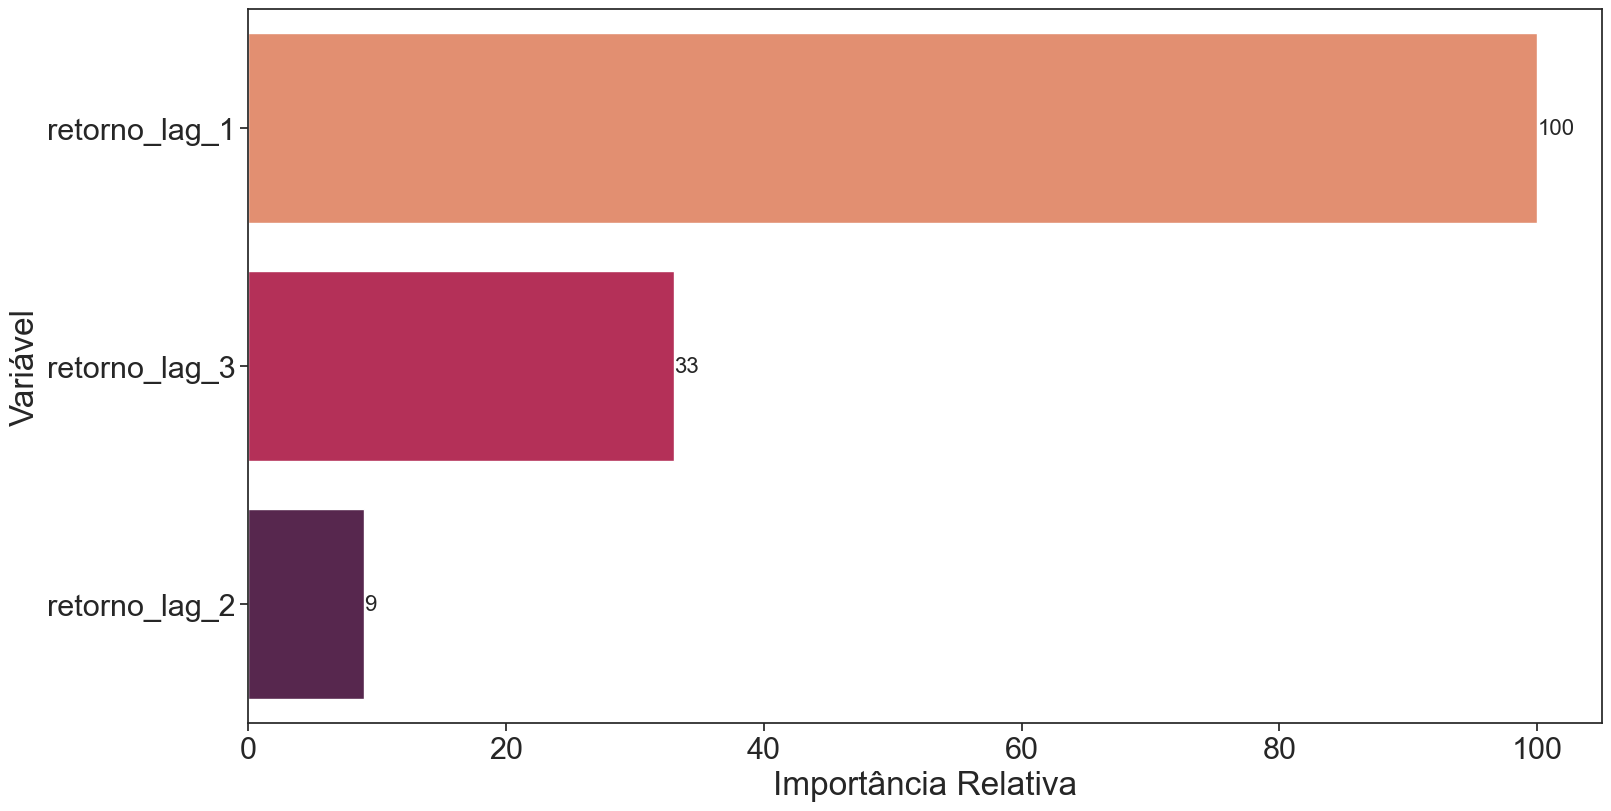

In [54]:
# VIP
plt.figure(figsize=(16, 8), layout = 'constrained')
sns.set(style = "ticks")
figure = sns.barplot(data = imp_df_gbm, x = 'importance_mean', y = 'feature', orient = 'h', 
                        err_kws={'linewidth': 0}, palette = "rocket_r", hue = 'feature')
plt.xlabel("Importância Relativa", fontsize = 24)
plt.ylabel("Variável", fontsize = 24)
plt.tick_params(axis = 'both', which = 'major', labelsize = 22)
for container in range(0, len(figure.containers)):
    plt.bar_label(figure.containers[container], fontsize = 16)
figure.get_figure().savefig( Path(figure_dir, 'vip_bagg' + '.png'), dpi = 400)

#### 9.3.3 Gráficos de Dependência Parcial (GBM)

PDPs do GBM são gerados para as principais features. Comparando visualmente com
os PDPs do Bagging (Seção 8.2), é possível avaliar se os dois modelos aprenderam
relações funcionais similares ou divergentes entre features e target.

In [55]:
# Seleciona as features para as quais queremos criar os PDPs
features = (imp_df_gbm
            .nlargest(5, columns = 'importance_mean') 
            ['feature']
            .to_list()
            )

# Cria os PDPs
for feature in features:
    plt.close()
    fig, ax = plt.subplots(figsize=(16, 9))
    PartialDependenceDisplay.from_estimator(opt_gbm, 
                            X_train, 
                            features = [feature], 
                            grid_resolution=100,
                            line_kw={"color": "#e60000"},
                            n_jobs = jobs,
                            ax=ax
                            )
    
    plt.xlabel(feature, fontsize = 22)
    plt.ylabel("Dependência Parcial", fontsize = 22)
    plt.tick_params(axis = 'both', which = 'major', labelsize = 18)
    sns.set(style = "ticks")
    fig.savefig(Path(figure_dir, f'pdp_gbm_{feature}.png'), dpi=400)
    plt.close()
    

# 10. LIMITAÇÕES  E PRÓXIMOS PASSOS

## 10.1 Limitações

- O conjunto de dados (apenas ~100 observações semanais, 1 ativo) é pequeno
  para modelos de ML — mais dados (mais ações ou período mais longo) melhorariam
  a generalização;
- As únicas features utilizadas foram defasagens de retorno e SELIC — features
  adicionais (indicadores técnicos, volatilidade, dados fundamentalistas) podem
  adicionar poder preditivo;
- O *target* (retorno semanal) tem baixa razão sinal-ruído, o que limita o
  $R^2$ máximo alcançável por qualquer modelo;
- `TimeSeriesSplit` com 5 folds em 100 observações gera folds de treino pequenos,
  aumentando a variância das estimativas de erro.

## 10.2 Extensões sugeridas

1. Expandir a análise para múltiplas ações, treinando modelos individuais ou
   um modelo *multi-output*;
2. Adicionar features exógenas: volatilidade histórica, indicadores técnicos
   (RSI, MACD), *spreads* de taxas de juros, dados macroeconômicos;
3. Testar outros algoritmos: Random Forest, XGBoost, LightGBM, CatBoost e
   redes neurais (MLP);
4. Implementar *walk-forward validation* com re-treino periódico, simulando
   um cenário real de uso do modelo ao longo do tempo;
5. Avaliar o modelo não apenas por métricas de erro (RMSE, MAPE), mas também
   por métricas financeiras: retorno acumulado de uma estratégia *long-short*
   baseada nas previsões, Sharpe ratio e máximo *drawdown*.